In [4]:
# from canvas import learn_game, play_game, human_interaction, move_arrowkeys, move_regression, move_classification
from torch_bc import AgentNetwork_Regression
import pickle
import pandas as pd
import random
import matplotlib.pyplot as plt
from canvas import play_game

from torchvision import transforms
from PIL import Image
import numpy as np

In [18]:
def preprocess_to_movement(action):
    ## (right - left, up - down) for (dx, dy)
    
    return (int(action[3]) - int(action[2]), int(action[0]) - int(action[1]))

df = pd.read_pickle('./datasets/screenshots-1k/ss-info.pkl')
# print(df.head())

print(df.iloc[1])
import torch
toExtract = ["agent_x", "agent_y", "target_x", "target_y"]
print("hello", df.loc[df.index[1], "movement"])
# idxs = [df.columns.get_loc(c) for c in toExtract]
state = df.iloc[1][toExtract].values
print(state)
row = df.iloc[1]["movement"]
print(row)
print(preprocess_to_movement(row))

# torch.tensor(row, dtype=torch.float32)

agent_x                            720
agent_y                            228
target_x                           363
target_y                           445
movement    (False, True, True, False)
Name: ss-1.png, dtype: object
hello (False, True, True, False)
[np.int64(720) np.int64(228) np.int64(363) np.int64(445)]
(False, True, True, False)
(-1, -1)


In [47]:
df["movement"] = df["movement"].apply(preprocess_to_movement)
df.head()

,agent_x,agent_y,target_x,target_y,movement
ss-0.png,79,137,5,562,"(-1, -1)"
ss-1.png,274,105,621,174,"(1, -1)"
ss-2.png,57,167,349,168,"(1, -1)"
ss-3.png,224,336,508,310,"(1, 1)"
ss-4.png,558,271,97,345,"(-1, -1)"


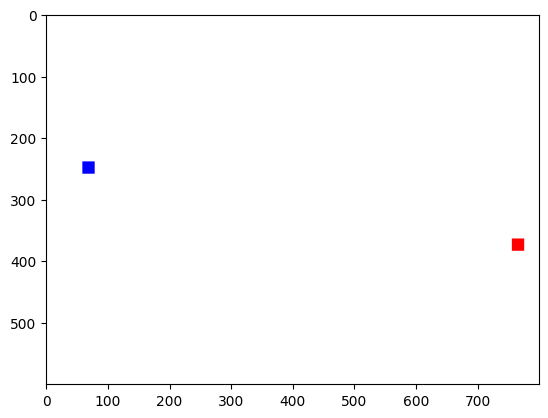

In [6]:
from torch_bc import PositionDataset

transform = transforms.Compose([
    transforms.ToTensor()
])

ss = "./datasets/ss-1k"
img = f"{ss}/ss-0.png"

demo = Image.open(img) 
# print(f"Image size: {demo.size}")

# demo_img = transform(demo)
# import torchvision
plt.imshow(demo)
# print(demo.getbands())
# torchvision.transforms.functional.to_pil_image(demo_img, mode=None)
# demo_array = demo_img.numpy()*255
# print(Image.fromarray(demo_array.astype(np.uint8)))
# plt.imshow(demo_img, cmap='gray')


In [ ]:
image = play_game(moveAgent="move_cnn", model=AgentNetwork_Regression())
plt.imshow(image)

: 

In [ ]:
dataset[1]

In [ ]:
# import matplotlib.pyplot as plt
# from tqdm import tqdm as progress

# params = {
#   "datasize": [100, 200, 500, 700, 1000],
#   "epochs": [10, 50, 100, 200],
#   "lr": [0.001, 0.01, 0.1],
#   "batch_size": [32, 64, 128],
#   "neurons": [32, 64, 128, 256],
# }

# results = {}

# for size in params["datasize"]:
  
#   modelName = f"regression-{"1k" if size == 1000 else size}.pth"
#   with open("./datasets/1k-targets.pkl", "rb") as f:
#     data = pickle.load(f)

#   points = int(len(data) * (size / 1000))  
#   samples = random.sample(data, points)
#   for epoch in (params["epochs"]):
#     for lr in params["lr"]:
#       for batchSize in params["batch_size"]:
#         for neurons in params["neurons"]:
#           print(f"### size: {size}, epoch: {epoch}, lr: {lr}, batchSize: {batchSize}, neurons: {neurons}")
          
#           model = AgentNetwork_Regression(epochs=epoch, lr=lr, batchSize=batchSize, npl=neurons).train_on_behaviour(data=samples, overwriteDevice="cpu", doPrints=False)
#           results[(size, epoch, lr, batchSize, neurons)] = model.get_training_losses()


In [ ]:
results